In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Any
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini")

In [4]:
class EvaluationSchema(BaseModel):
    score: int = Field(description="Score assigned to the essay based on the evaluation criteria from 0 to 10.", ge=0, le=10)
    feedback: str = Field(description="Detailed Feedback on the essay, including strengths and areas for improvement.")

In [5]:
structured_model = model.with_structured_output(EvaluationSchema)

In [6]:
essay = """"# Education: The Most Powerful Instrument of Social Transformation

## Introduction

Nelson Mandela once remarked that “Education is the most powerful weapon which you can use to change the world.” Throughout human history, education has served as the foundation upon which civilizations have built their social, economic, political, and cultural progress. From the ancient universities of Nalanda and Takshashila to the modern digital classrooms of the twenty-first century, education has remained the primary means through which knowledge is transmitted, innovation is fostered, and human potential is realized.

In a developing country like India, where diversity coexists with inequality, education assumes an even greater significance. It is not merely a tool for acquiring knowledge or securing employment; it is an instrument of empowerment, social mobility, nation-building, and democratic participation. The future of any society is determined not by the wealth it possesses today but by the quality of education it provides to its citizens.

## Education and Individual Empowerment

Education plays a crucial role in shaping an individual's personality, character, and worldview. It develops critical thinking, analytical abilities, creativity, and decision-making skills. An educated person is better equipped to understand opportunities, exercise rights, and fulfill responsibilities.

Education enables individuals to break free from the cycle of poverty and dependence. It enhances employability and productivity while opening doors to economic opportunities. More importantly, it instills confidence and self-respect, allowing individuals to become active participants in society rather than passive recipients of welfare.

For women, education serves as a powerful tool of empowerment. Studies consistently show that educated women are more likely to participate in the workforce, make informed healthcare decisions, and contribute to the education of future generations. Thus, educating a woman often results in educating an entire family.

## Education as a Driver of Economic Development

Human capital is increasingly recognized as the most valuable asset in the modern knowledge economy. Nations that invest heavily in education tend to achieve higher levels of economic growth, innovation, and competitiveness.

Education enhances labor productivity, promotes entrepreneurship, and facilitates technological advancement. Countries such as Japan, South Korea, and Singapore transformed themselves from resource-scarce economies into global economic powers primarily through investments in education and skill development.

For India, with its large youthful population, education is essential for harnessing the demographic dividend. A skilled and educated workforce can drive growth in emerging sectors such as artificial intelligence, biotechnology, renewable energy, and advanced manufacturing. Conversely, inadequate education may convert the demographic dividend into a demographic burden.

The National Education Policy (NEP) 2020 recognizes this reality by emphasizing multidisciplinary learning, skill development, and flexibility in education to meet the demands of the future economy.

## Education and Social Equality

One of the most significant contributions of education is its ability to reduce social inequalities. Historically marginalized communities often face barriers related to caste, gender, region, and economic status. Education provides a pathway toward social mobility and inclusion.

The Constitution of India envisions a society based on justice, liberty, equality, and fraternity. Education helps translate these constitutional ideals into reality by providing equal opportunities to all citizens. Programs such as the Right to Education Act, scholarships for disadvantaged groups, and initiatives promoting girls' education aim to bridge longstanding social divides.

Education also promotes social awareness and challenges discriminatory practices. It encourages individuals to question prejudices and embrace values of tolerance, inclusiveness, and mutual respect. In a diverse country like India, education acts as a unifying force that strengthens national integration while celebrating cultural pluralism.

## Education and Democratic Governance

Democracy thrives when citizens are informed, aware, and capable of critical reasoning. Education strengthens democratic institutions by creating responsible citizens who can participate meaningfully in governance.

An educated population is better able to evaluate public policies, hold governments accountable, and engage constructively in civic affairs. Education promotes constitutional values, respect for the rule of law, and commitment to democratic principles.

Furthermore, education combats misinformation, extremism, and divisive ideologies by fostering scientific temper and rational thinking. Article 51A of the Constitution emphasizes the development of scientific temper, humanism, and the spirit of inquiry—qualities that are nurtured through education.

In an era of social media and information overload, education is indispensable for distinguishing facts from falsehoods and ensuring informed public discourse.

## Education in the Age of Technology

The twenty-first century has witnessed unprecedented technological transformation. Digital technologies, artificial intelligence, automation, and big data are reshaping economies and societies. Consequently, the nature of education itself is evolving.

Technology has expanded access to learning through online platforms, virtual classrooms, and digital resources. During the COVID-19 pandemic, digital education played a critical role in ensuring continuity of learning despite widespread disruptions.

However, technological advancement also presents challenges. The digital divide continues to exclude millions from educational opportunities due to inadequate internet connectivity, lack of devices, and limited digital literacy. Bridging this divide is essential to ensure equitable access to quality education.

The future of education lies not merely in adopting technology but in integrating it thoughtfully with human values, creativity, ethics, and critical thinking. Machines may process information, but education must continue to cultivate wisdom and judgment.

## Challenges Facing Education in India

Despite significant progress, India's education system continues to face several challenges.

First, disparities in access and quality persist across regions, socioeconomic groups, and genders. Rural schools often lack adequate infrastructure, qualified teachers, and learning resources.

Second, learning outcomes remain a concern. Enrollment rates have improved considerably, but many students struggle with foundational literacy and numeracy skills.

Third, the examination-oriented approach frequently emphasizes rote learning over conceptual understanding, creativity, and problem-solving.

Fourth, there is often a mismatch between educational curricula and industry requirements, leading to skill gaps and unemployment among graduates.

Finally, public expenditure on education remains lower than desirable levels. Sustained investment is necessary to improve infrastructure, teacher training, research, and innovation.

Addressing these challenges requires collaborative efforts from governments, educational institutions, civil society, and the private sector.

## The Way Forward

The future of education should be guided by the principles of accessibility, quality, equity, and relevance.

Greater investment in school infrastructure, teacher capacity building, and digital connectivity is essential. Foundational literacy and numeracy must receive priority, as they form the basis of lifelong learning.

Education should move beyond memorization toward experiential learning, critical thinking, creativity, and interdisciplinary approaches. Greater emphasis must be placed on vocational training, entrepreneurship, and life skills to prepare students for a rapidly changing world.

Inclusive policies must ensure that no child is left behind because of economic hardship, gender discrimination, disability, or geographical location. Simultaneously, research, innovation, and higher education institutions should be strengthened to position India as a global knowledge leader.

Most importantly, education must nurture not only skilled professionals but also ethical citizens committed to the welfare of society and the planet.

## Conclusion

Education is far more than a means of acquiring degrees or securing employment. It is the foundation of human development, social justice, economic prosperity, and democratic governance. It empowers individuals, transforms communities, and shapes the destiny of nations.

As India aspires to become a developed nation in the coming decades, education will remain the cornerstone of its progress. The true measure of a country's success lies not in the size of its economy or the strength of its institutions alone, but in the extent to which it educates, empowers, and enlightens its people.

An educated society is not merely a prosperous society; it is a just, inclusive, innovative, and resilient society. Therefore, investing in education is ultimately an investment in the future of humanity itself.
"""

In [7]:
prompt = f"Evaluate the language quality of the following essay on a scale of 0 to 10, where 0 indicates poor language quality and 10 indicates excellent language quality. Provide a detailed explanation for the assigned score, highlighting the strengths and weaknesses of the essay's language use.\n\nEssay:\n{essay}"
structured_model.invoke(prompt)

EvaluationSchema(score=9, feedback='The essay demonstrates a high level of language quality, characterized by clear organization, well-structured paragraphs, a strong vocabulary, and meaningful arguments.\n\n**Strengths:**  \n1. **Clarity and Cohesion:** The essay is logically organized with clear sections that flow well from one idea to the next. Each paragraph serves a specific purpose that contributes to the overall thesis. \n2. **Vocabulary and Style:** The language used is appropriate for an academic setting, employing a rich vocabulary that conveys complex ideas effectively. Phrases such as \'demographic dividend,\' \'experiential learning,\' and \'critical reasoning\' reflect a sophisticated understanding of education\'s role in society. \n3. **Argument Development:** The essay presents well-supported arguments with relevant examples, such as the success stories of countries like Japan and South Korea. This strengthens the credibility of the claims made about education and its i

In [8]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str

    individual_scores: Annotated[List[int], operator.add]
    average_score: float



In [9]:
def evaluate_language(essay: UPSCState) -> UPSCState:
    prompt = f"Evaluate the language quality of the following essay on a scale of 0 to 10, where 0 indicates poor language quality and 10 indicates excellent language quality. Provide a detailed explanation for the assigned score, highlighting the strengths and weaknesses of the essay's language use.\n\nEssay:\n{essay['essay']}"
    result = structured_model.invoke(prompt)
    return {"language_feedback": result.feedback, "individual_scores": [result.score]}

def evaluate_analysis(essay: UPSCState) -> UPSCState:
    prompt = f"Evaluate the depth and quality of analysis in the following essay on a scale of 0 to 10, where 0 indicates poor analysis and 10 indicates excellent analysis. Provide a detailed explanation for the assigned score, highlighting the strengths and weaknesses of the essay's analytical approach.\n\nEssay:\n{essay['essay']}"
    result = structured_model.invoke(prompt)
    return {"analysis_feedback": result.feedback, "individual_scores": [result.score]}

def evaluate_clarity(essay: UPSCState) -> UPSCState:
    prompt = f"Evaluate the clarity and coherence of the following essay on a scale of 0 to 10, where 0 indicates poor clarity and 10 indicates excellent clarity. Provide a detailed explanation for the assigned score, highlighting the strengths and weaknesses of the essay's organization and expression.\n\nEssay:\n{essay['essay']}"
    result = structured_model.invoke(prompt)
    return {"clarity_feedback": result.feedback, "individual_scores": [result.score]}

def evaluate_overall(essay: UPSCState) -> UPSCState:
    prompt = f"Given the follwing feedbacks on language, analysis and clarity, evaluate the overall quality of the essay on a scale of 0 to 10, where 0 indicates poor quality and 10 indicates excellent quality. Provide a detailed explanation for the assigned score, highlighting the strengths and weaknesses of the essay as a whole.\n\nEssay:\n{essay['essay']}\n\nLanguage Feedback:\n{essay['language_feedback']}\n\nAnalysis Feedback:\n{essay['analysis_feedback']}\n\nClarity Feedback:\n{essay['clarity_feedback']}"
    result = structured_model.invoke(prompt)

    sum_scores = sum(essay['individual_scores'])
    return {"overall_feedback": result.feedback, "individual_scores": [sum_scores]}

In [10]:
graph = StateGraph(UPSCState)

In [11]:
graph.add_node('language_evaluation', evaluate_language)
graph.add_node('analysis_evaluation', evaluate_analysis)
graph.add_node('clarity_evaluation', evaluate_clarity)
graph.add_node('overall_evaluation', evaluate_overall)

In [12]:
graph.add_edge(START, "language_evaluation")
graph.add_edge(START, "analysis_evaluation")
graph.add_edge(START, "clarity_evaluation")

graph.add_edge("language_evaluation", "overall_evaluation")
graph.add_edge("analysis_evaluation", "overall_evaluation")
graph.add_edge("clarity_evaluation", "overall_evaluation")

graph.add_edge("overall_evaluation", END)

In [13]:
workflow = graph.compile()

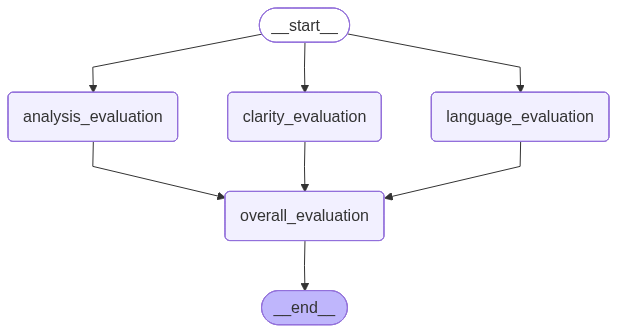

In [14]:
workflow

In [15]:
initial_state = {
    "essay": essay}

final_state = workflow.invoke(initial_state)

In [16]:
final_state

{'essay': '"# Education: The Most Powerful Instrument of Social Transformation\n\n## Introduction\n\nNelson Mandela once remarked that “Education is the most powerful weapon which you can use to change the world.” Throughout human history, education has served as the foundation upon which civilizations have built their social, economic, political, and cultural progress. From the ancient universities of Nalanda and Takshashila to the modern digital classrooms of the twenty-first century, education has remained the primary means through which knowledge is transmitted, innovation is fostered, and human potential is realized.\n\nIn a developing country like India, where diversity coexists with inequality, education assumes an even greater significance. It is not merely a tool for acquiring knowledge or securing employment; it is an instrument of empowerment, social mobility, nation-building, and democratic participation. The future of any society is determined not by the wealth it possesse